In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("cleaned_dataset.csv")

In [4]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,CITY,STATE,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,ORDER_YEAR,ORDER_MONTH,ORDER_QUARTER
0,10107,30,95.70,2,2871.00,2003-02-24,Shipped,1,2,2003,...,NYC,NY,10022,USA,Yu,Kwai,Small,2003,2,1
1,10121,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,...,Reims,Unknown,51100,France,Henriot,Paul,Small,2003,5,2
2,10134,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,...,Paris,Unknown,75508,France,Da Cunha,Daniel,Medium,2003,7,3
3,10145,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,...,Pasadena,CA,90003,USA,Young,Julie,Medium,2003,8,3
4,10159,49,100.00,14,5205.27,2003-10-10,Shipped,4,10,2003,...,San Francisco,CA,Unknown,USA,Brown,Julie,Medium,2003,10,4


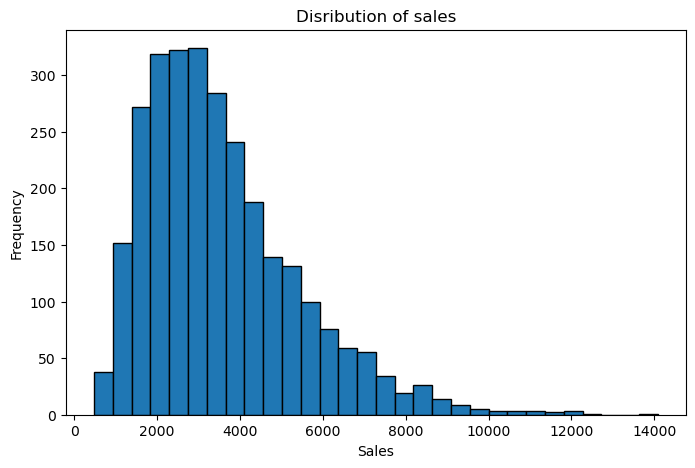

In [5]:
#Histogram - Distribution of sales

plt.figure(figsize=(8,5))

plt.hist(df["SALES"], bins=30, edgecolor="black")

plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Disribution of sales")

plt.show()

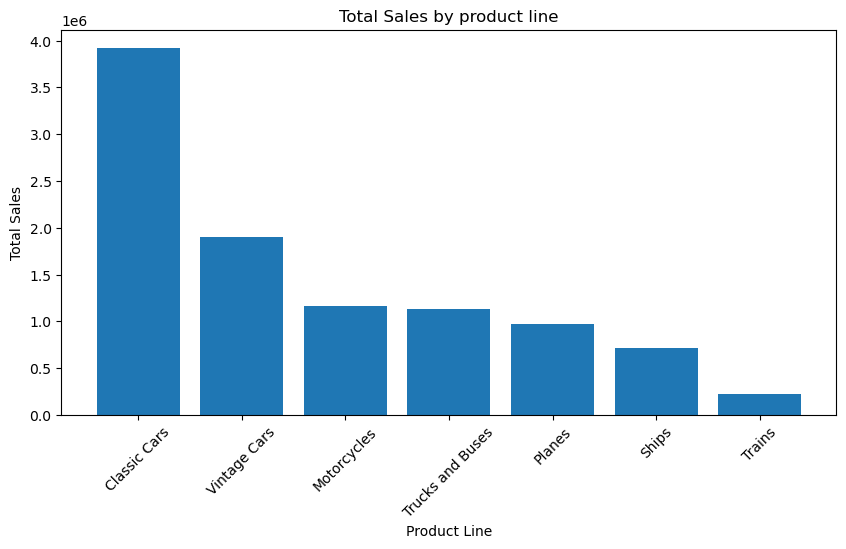

In [6]:
#Bar chart - Sales by Product line

product_sales = df.groupby("PRODUCTLINE")["SALES"].sum()
product_sales = product_sales.sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(product_sales.index, product_sales.values)

plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.title("Total Sales by product line")

plt.xticks(rotation = 45)

plt.show()

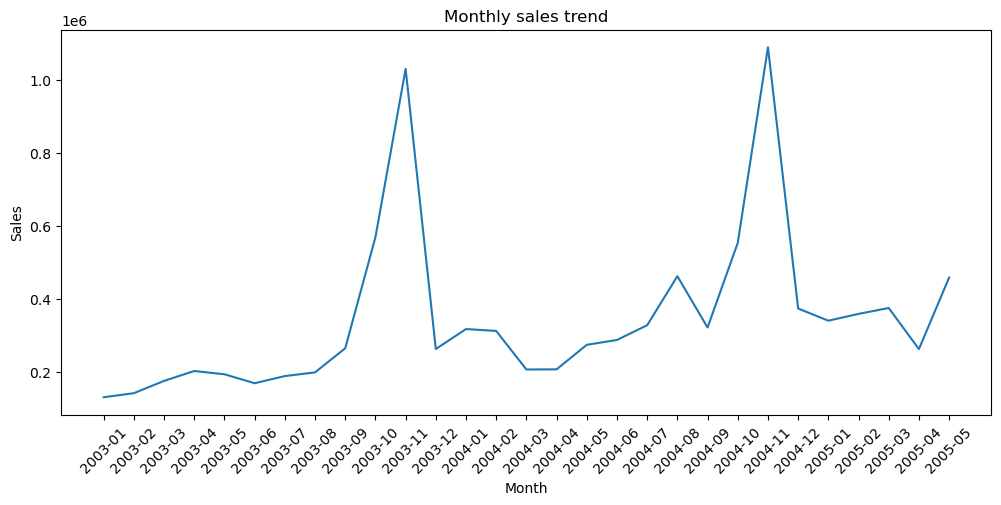

In [7]:
#Line chart- Sales over time

df["ORDERDATE"].dtype
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])
# df["ORDERDATE"].dtype

monthly_sales = df.groupby(
    df["ORDERDATE"].dt.to_period("M")
)["SALES"].sum()


#plot

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly sales trend")

plt.xticks(rotation=45)

plt.show()

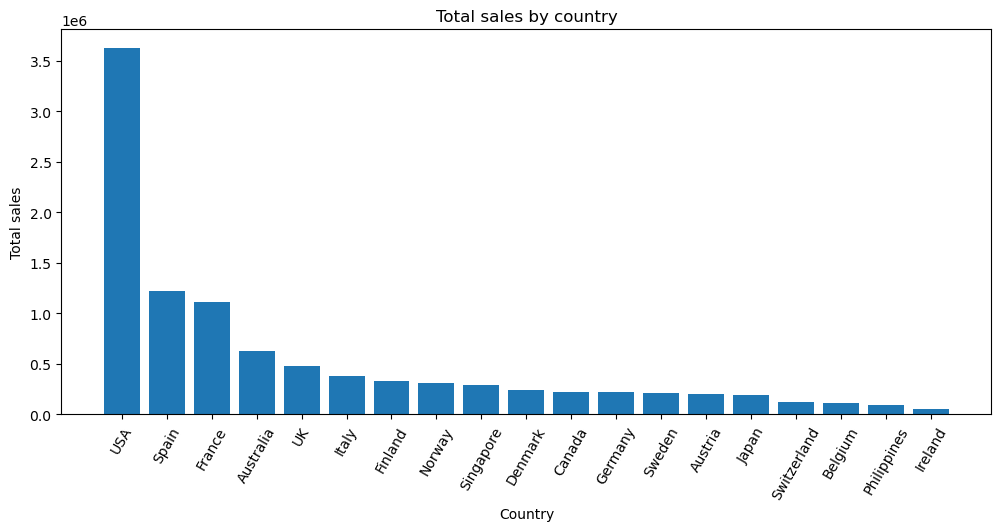

In [8]:
# Sales by each country- bar chart

country_sales = df.groupby("COUNTRY")["SALES"].sum()
country_sales = country_sales.sort_values(ascending=False)

plt.figure(figsize=(12,5))

plt.bar(country_sales.index, country_sales.values)

plt.xlabel("Country")
plt.ylabel("Total sales")
plt.title("Total sales by country")

plt.xticks(rotation=60)
plt.show()

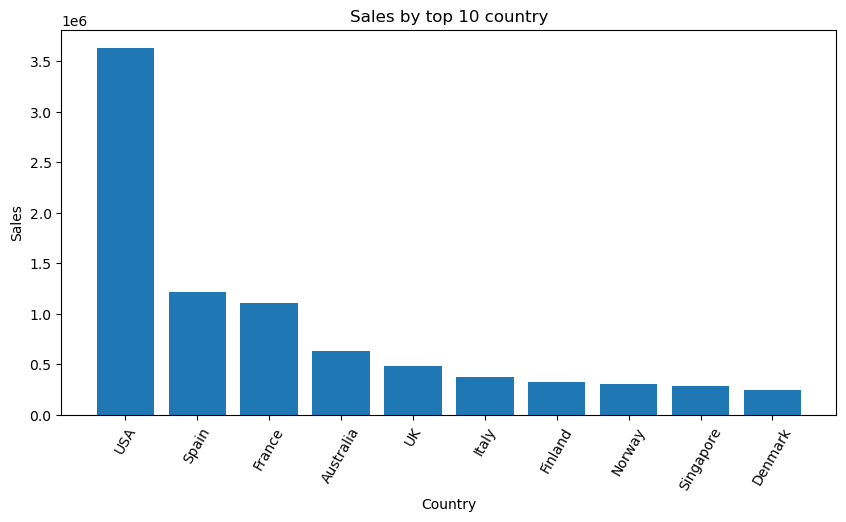

In [9]:
# for top countries 

top_countries = country_sales.head(10)

plt.figure(figsize=(10,5))

plt.bar(top_countries.index, top_countries.values)

plt.xlabel("Country")
plt.ylabel("Sales")
plt.title("Sales by top 10 country")

plt.xticks(rotation=60)
plt.show()

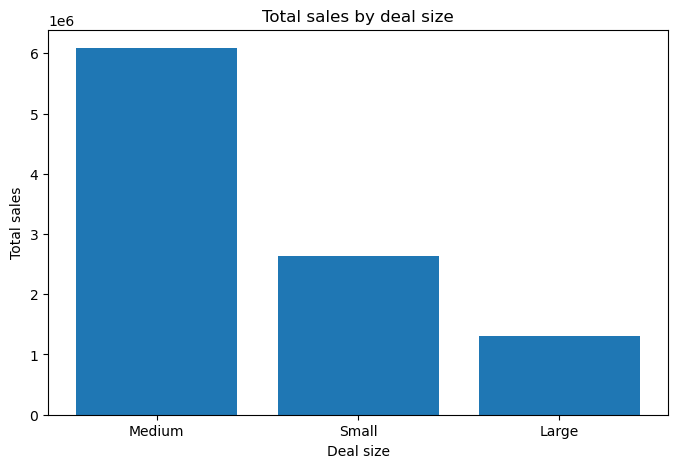

In [10]:
#Sales by dealsize

deal_sales = df.groupby("DEALSIZE")["SALES"].sum()

deal_sales =deal_sales.sort_values(ascending=False)

plt.figure(figsize=(8,5))


plt.bar(deal_sales.index, deal_sales.values)
plt.title("Total sales by deal size")
plt.xlabel("Deal size")
plt.ylabel("Total sales")

plt.show()

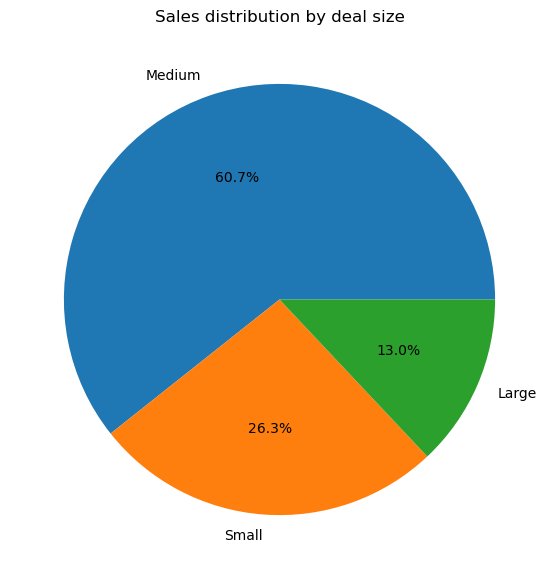

In [11]:
#pie chart for deal size

plt.figure(figsize=(7,7))

plt.pie(
    deal_sales.values,
    labels = deal_sales.index,
    autopct="%1.1f%%"
)

plt.title("Sales distribution by deal size")
plt.show()

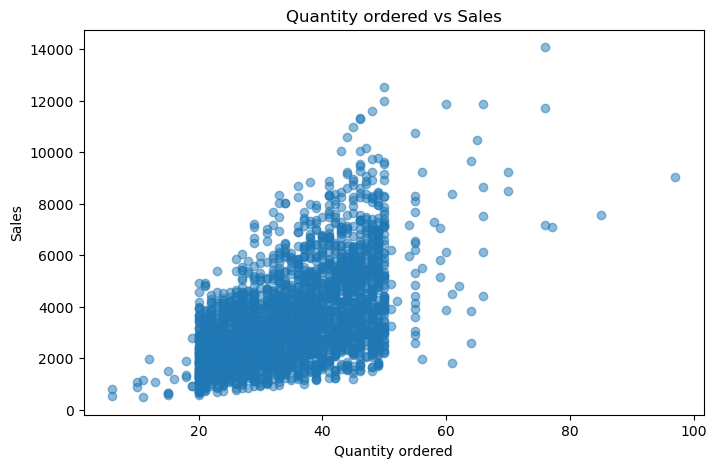

In [19]:
#Quantity ordered vs Sales

plt.figure(figsize=(8,5))

plt.scatter(
    df["QUANTITYORDERED"],
    df["SALES"],
    alpha=0.5
)

plt.xlabel("Quantity ordered")
plt.ylabel("Sales")
plt.title("Quantity ordered vs Sales")

plt.show()

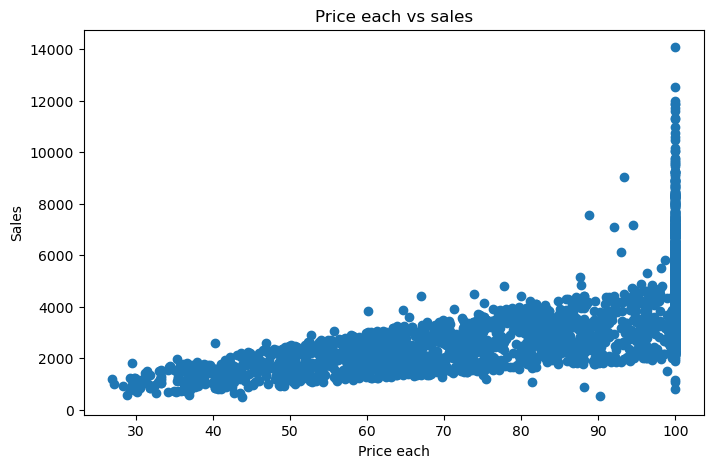

In [17]:
#Price each vs Sales

plt.figure(figsize=(8,5))

plt.scatter(
    df["PRICEEACH"],
    df["SALES"]
)

plt.xlabel("Price each")
plt.ylabel("Sales")
plt.title("Price each vs sales")

plt.show()

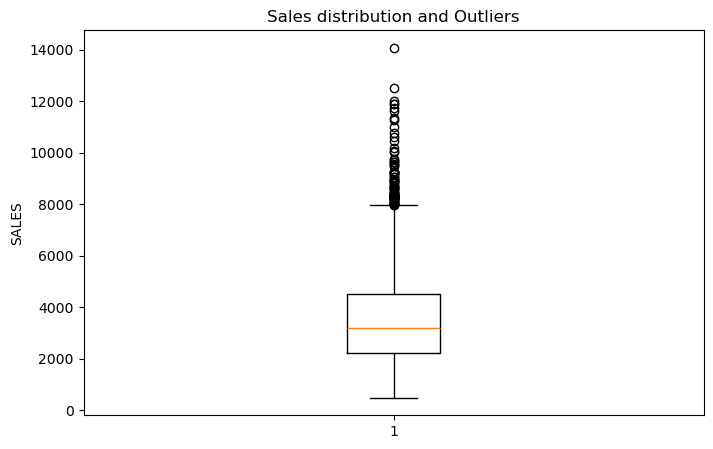

In [18]:
#Sales distribution and outliers

plt.figure(figsize=(8,5))

plt.boxplot(df["SALES"])

plt.ylabel("SALES")
plt.title("Sales distribution and Outliers")

plt.show()

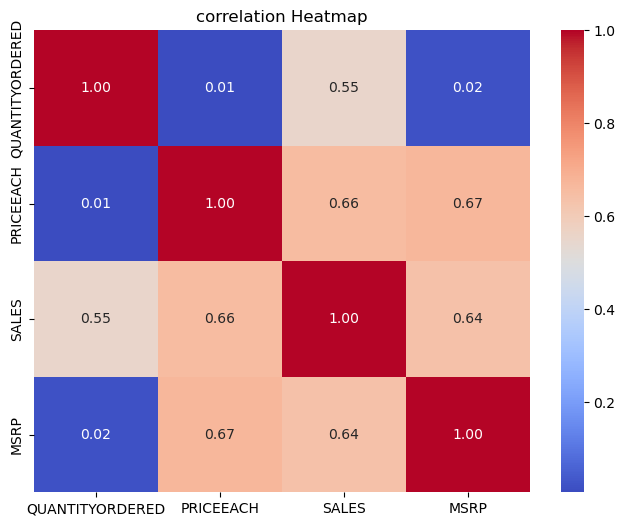

In [26]:
#Correlation Heatmap

import seaborn as sns


corr = df[[
    "QUANTITYORDERED",
    "PRICEEACH",
    "SALES",
    "MSRP"
]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("correlation Heatmap")

plt.show()

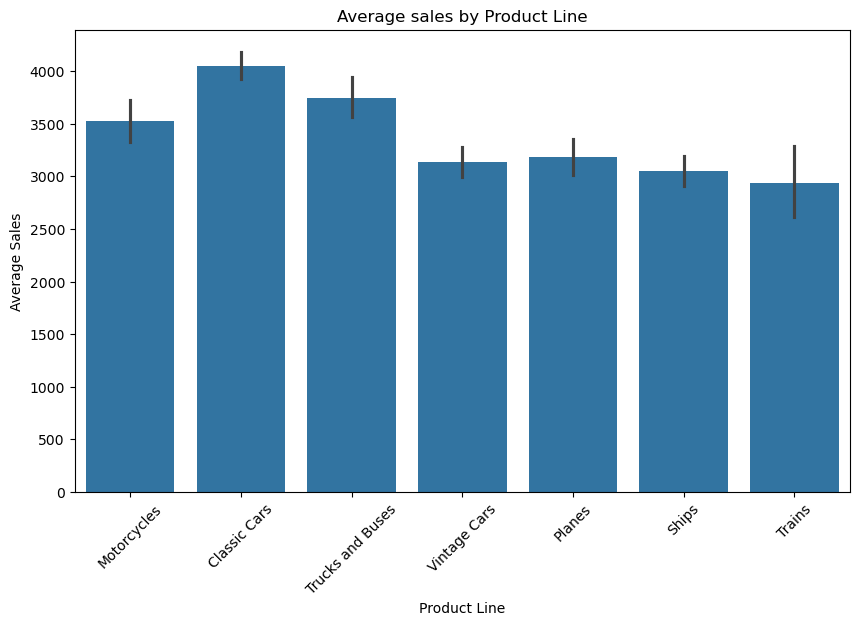

In [28]:
# Categorical analysis

plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="PRODUCTLINE",
    y="SALES",
    estimator="mean"
)

plt.xlabel("Product Line")
plt.ylabel("Average Sales")
plt.title("Average sales by Product Line")

plt.xticks(rotation=45)

plt.show()